在前面的课程里，我们已经学习到了MLP的部分。我们接下来的课程里将会继续讲到recurrent neural networks以及其诸多变体，这固然是十分令人感到兴奋的。然而，在继续学习之前，karpathy 认为我们需要暂时多留一节课下来不着急继续进行，因为尽管我们在前面的课程里训练了MLP，并且也取得不错的loss，但是我们在梯度的反向传播部分并没有深入太多。所以这节课我们将把原来代码里的backward部分去掉，换成我们自己写的backprop代码，来帮助我们理解梯度反向传播的过程。

在此之前，我们已经实现了micrograd，里面也有梯度反向传播的代码，但是那只是在单独的标量层面。这和从tensor的角度来说还是有些不同的，所以micrograd里的例子可能并不能很好的帮助我们理解像是pytorch里的autograd的部分。所以尽管我们在01课程里已经实现了反向传播的代码，这节课里我们还是重新再来写一遍backward。

首先不得不承认，如今人们已经很少手写反向传播的代码，大部分人都是直接 loss.backward() ,但是在以前，人们还是得手动去完成backprop的部分。karpathy列举了2006年和2014年的两篇论文，在那里研究者都是手写backward的

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


上面的代码和之前课程里的都是一样的，下面我们开始进入正题：

首先，为了方便对比手动梯度和pytorch的区别，我们先创建一个用于比较的 utility 函数

In [6]:
# utility function we will use later when comparing manual gradients to PyTorch gradients，这是用于比较手动梯度和PyTorch梯度的实用函数
def cmp(s, dt, t):
  ex = torch.all(dt == t.grad).item()
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item() 
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

下面是一些参数的初始化部分，这里和之前的课程还是有所区别，做了一些改动，比如说这里的权重和偏置我们都尽量变成小的数值。通常可能会把bias都设置为0，这里是设置成尽量小的数据，因为如果设置为0可能会引发梯度的一些错误。

In [7]:
n_embd = 10         # the dimensionality of the character embedding vectors, 每个字符用一个10维的向量表示
n_hidden = 64       # the number of neurons in the hidden layer of the MLP, MLP隐藏层的神经元数量

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)      # character embedding table, 字符嵌入表
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.
# 注意：我以非标准方式初始化了许多这些参数，因为有时以例如全零进行初始化可能会掩盖反向传播实现中的错误。

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))    # number of parameters in total，总参数数量
for p in parameters:
  p.requires_grad = True

4137


In [8]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

这里的forward pass部分和我们之前课程里的有着明显的不同，我们拓展了许多代码，主要原因如下：

首先，我们把 loss = F.cross_entropy(logits,Yb) 这里的交叉熵损失函数给展开成立完整的表述，原本它是自动执行 LogSoftmax + 负对数似然损失(NLL Loss)
现在我们手动来实现这一步骤
- 首先找到logits里的最大值，然后将所有的logits减去这个最大值进行标准化，这一步是为了防止后续logits进行exp操作时数据溢出(从数学上可以证明减去同样值之后对所有的结果没有影响)
- 然后将exp后的数据求和，并且不用除法来表示 /sum ，用sum的负一次方来表示，这是为了后续求梯度的方便
- 最后分别计算exp后数据的概率，然后再对其取对数、取负数

其次，我们把原本的步骤分散成一个个可以管理的组块，这样我们在正向传播过程种能得到更多的中间tensor，于是在后续梯度的反向传播backward时进行梯度计算会更加方便


In [9]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))  这里是手动实现交叉熵损失，先找出最大值，然后每个都减去，接着计算概率和对数概率，最后计算损失
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...  用-1次方来保证梯度计算
probs = counts * counts_sum_inv
logprobs = probs.log()    # logprobs 的形状是 [32，27]，其中32是批量大小，27是词汇表大小。每个元素表示在给定输入的情况下预测下一个字符的概率的对数值。
loss = -logprobs[range(n), Yb].mean()   # range(n)表示第几行，Yb表示第几列，这样就可以找到正确的概率值，取负号是因为交叉熵损失是负对数概率，最后取平均值

# PyTorch backward pass 这里告诉pytorch这些数据需要求导，以便于后续的反向传播计算梯度的验证等等
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3389, grad_fn=<NegBackward0>)

首先，我们需要手动计算整个过程中 各项参数变量的梯度 ， 并与pytorch 计算出的标准值比对

In [10]:
# Exercise 1: backprop through the whole thing manually, 
# backpropagating through exactly all of the variables 
# as they are defined in the forward pass above, one by one
# 练习1：手动对整个计算过程进行反向传播，逐个地、精确地经过上面前向传播中定义的所有变量

dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0/n      # 这里因为对于每一个样本，只有正确的位置的梯度是-1.0/n，其他位置保持为0，类比就是 loss=a+b+c，对于a来说，dloss/da=1，db=0，dc=0
dprobs = (1.0 / probs) * dlogprobs    # dx=dL/dx=dL/dy*dy/dx, 这里的y是logprobs，x是probs，所以需要乘以1/probs
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)  # probs = counts * 1/S，所以dprobs/d(1/S) = counts，所以dL/d(1/S)=dL/dprobs * dprobs/d(1/S)
# probs = counts * counts_sum_inv，但是counts和counts_sum_inv之间有关联，所以这里 counts 通过两条路影响 probs
# 1：counts 作为分子，变大直接让 probs 变大（分母不变时）2：counts 变大导致分母 S 变大，分母变大反过来让 probs 变小
# 所以这里需要分开处理两条路的梯度，第一条路是直接通过分子，第二条路是通过分母的关系
dcounts = counts_sum_inv * dprobs   
# 这里只计算“路1”的梯度。把 counts_sum_inv（即 1/S）看作常数系数 k。
# 因为 probs = k * counts，类比 y = k * x，那么 dy/dx = k。即 dL/dprobs（路1部分）= dcounts * k
# 所以 dL/dcounts（仅路1部分）= dprobs * k = dprobs * counts_sum_inv。
# 此时先不考虑 counts 变化对分母 S 造成的影响。
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
# 现在开始处理“路2”：counts 变化 -> 总和 S 变化 -> 1/S 变化 -> probs 变化。
# 首先，我们已经算出了 dcounts_sum_inv，它表示“损失 L 对 1/S 的导数” (dL/d(1/S))。
# 我们想知道“损失 L 对总和 S 的导数” (dL/dS)。
# 因为 1/S 对 S 求导是 -1/(S^2)，即 -counts_sum**-2。
# 类比链式法则：dL/dS = dL/d(1/S) * d(1/S)/dS = dcounts_sum_inv * (-counts_sum**-2)。
# 所以这行算出了 dL/dS，暂记为 dcounts_sum。
dcounts += torch.ones_like(counts) * dcounts_sum   
# 刚才算出了 dL/dS（损失对总和的梯度），现在要把这个梯度传回给每一个具体的 counts 元素。
# 因为总和 S = c1 + c2 + c3 + ...（即所有 counts 元素相加）。
# 对于任意一个 counts 元素 c_i，总有 dS/dc_i = 1（因为加和对每个元素的导数都是1）。
# 类比：若 S = a + b + c，则 dS/da = 1，dS/db = 1，dS/dc = 1。
# 所以 dL/dc_i（路2部分）= dL/dS * dS/dc_i = dcounts_sum * 1。
# 由于每个 c_i 的导数都是1，所以直接用 torch.ones_like(counts) 乘上 dcounts_sum，
# 把这个结果累加到第一行算出的“路1”结果上。两条路相加，才是最终的 dcounts。 
dnorm_logits = counts * dcounts   # counts = exp(norm_logits)，所以 dcounts/dnorm_logits = counts。类比 y = exp(x)，dy/dx = y = exp(x)。 所以 dL/dnorm_logits = dL/dcounts * dcounts/dnorm_logits = dcounts * counts。
dlogits = dnorm_logits.clone()  # norm_logits = logits - logit_maxes，所以 dnorm_logits/dlogits = 1，类比 y = x - k，其中 k 是常数，那么 dy/dx = 1。所以 dL/dlogits = dL/dnorm_logits * dnorm_logits/dlogits = dnorm_logits * 1 = dnorm_logits。
dlogit_maxes = (-dnorm_logits).sum(1, keepdim=True) # norm_logits = logits - logit_maxes，所以 dnorm_logits/dlogit_maxes = -1，类比 y = x - k，其中 k 是 logit_maxes，那么 dy/dk = -1。所以 dL/dlogit_maxes = dL/dnorm_logits * dnorm_logits/dlogit_maxes = dnorm_logits * (-1) = -dnorm_logits。
dlogits += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes # 因为 logit_maxes 是 logits 中每行的最大值，所以它只影响那个最大值所在位置的 logits。对于其他位置，dlogit_maxes 的梯度不传递（因为它们不受 logit_maxes 影响）。对于最大值所在位置的 logits，它受到两个部分的梯度影响：一部分是 dnorm_logits 直接传递过来的 dlogits，另一部分是 dlogit_maxes 通过 logit_maxes 传递过来的梯度。
dh = dlogits @ W2.T # 因为 logits = h @ W2 + b2，所以 dlogits/dh = W2.T（类比 y = x @ W + b，dy/dx = W.T）。所以 dL/dh = dL/dlogits * dlogits/dh = dlogits @ W2.T。
dW2 = h.T @ dlogits # 因为 logits = h @ W2 + b2，所以 dlogits/dW2 = h.T（类比 y = x @ W + b，dy/dW = x.T）。所以 dL/dW2 = dL/dlogits * dlogits/dW2 = h.T @ dlogits。
db2 = dlogits.sum(0)  # 因为 logits = h @ W2 + b2，所以 dlogits/db2 = 1（类比 y = x @ W + b，dy/db = 1）。所以 dL/db2 = dL/dlogits * dlogits/db2 = dlogits.sum(0)。
dhpreact = (1.0 - h**2) * dh  # 因为 h = tanh(hpreact)，所以 dh/dhpreact = 1 - tanh^2(hpreact) = 1 - h^2（类比 y = tanh(x)，dy/dx = 1 - tanh^2(x)）。所以 dL/dhpreact = dL/dh * dh/dhpreact = dh * (1 - h**2)。
dbngain = (bnraw * dhpreact).sum(0, keepdim=True) # 因为 hpreact = bngain * bnraw + bnbias，所以 dhpreact/dbngain = bnraw（类比 y = k * x + b，其中 k 是 bngain，那么 dy/dk = x）。所以 dL/dbngain = dL/dhpreact * dhpreact/dbngain = (bnraw * dhpreact).sum(0, keepdim=True)。
dbnraw = bngain * dhpreact  # 因为 hpreact = bngain * bnraw + bnbias，所以 dhpreact/dbnraw = bngain（类比 y = k * x + b，其中 k 是 bngain，那么 dy/dx = k）。所以 dL/dbnraw = dL/dhpreact * dhpreact/dbnraw = bngain * dhpreact。
dbnbias = dhpreact.sum(0, keepdim=True) # 因为 hpreact = bngain * bnraw + bnbias，所以 dhpreact/dbnbias = 1（类比 y = k * x + b，其中 b 是 bnbias，那么 dy/db = 1）。所以 dL/dbnbias = dL/dhpreact * dhpreact/dbnbias = dhpreact.sum(0, keepdim=True)。
dbndiff = bnvar_inv * dbnraw  # 因为 bnraw = bndiff * bnvar_inv，所以 dbnraw/dbndiff = bnvar_inv（类比 y = k * x，其中 k 是 bnvar_inv，那么 dy/dx = k）。所以 dL/dbndiff = dL/dbnraw * dbnraw/dbndiff = bnvar_inv * dbnraw。
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True) # 因为 bnraw = bndiff * bnvar_inv，所以 dbnraw/dbnvar_inv = bndiff（类比 y = k * x，其中 k 是 bndiff，那么 dy/dk = x）。所以 dL/dbnvar_inv = dL/dbnraw * dbnraw/dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)。
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv # 因为 bnvar_inv = (bnvar + 1e-5)**-0.5，所以 dbnvar_inv/dbnvar = -0.5 * (bnvar + 1e-5)**-1.5（类比 y = (x + c)**-0.5，其中 c 是常数，那么 dy/dx = -0.5 * (x + c)**-1.5）。所以 dL/dbnvar = dL/dbnvar_inv * dbnvar_inv/dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv。
dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar  # 因为 bnvar = 1/(n-1) * bndiff2.sum(0)，所以 dbnvar/dbndiff2 = 1/(n-1)（类比 y = (1/(n-1)) * sum(x_i)，那么 dy/dx_i = 1/(n-1)）。所以 dL/dbndiff2 = dL/dbnvar * dbnvar/dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar。
dbndiff += (2*bndiff) * dbndiff2  # 因为 bndiff2 = bndiff**2，所以 dbndiff2/dbndiff = 2 * bndiff（类比 y = x^2，那么 dy/dx = 2x）。所以 dL/dbndiff = dL/dbndiff + dL/dbndiff2 * dbndiff2/dbndiff = dbndiff + (2*bndiff) * dbndiff2。
dhprebn = dbndiff.clone() # 因为 hprebn = bnmeani + bndiff，所以 dhprebn/dbndiff = 1（类比 y = k + x，其中 k 是 bnmeani，那么 dy/dx = 1）。所以 dL/dhprebn = dL/dbndiff * dbndiff/dhprebn = dbndiff。
dbnmeani = (-dbndiff).sum(0)  
# 虽然 hprebn = bnmeani + bndiff，但 bndiff 的前向定义是 bndiff = hprebn_原始 - bnmeani。
# 所以 bnmeani 变化时，bndiff 会反向变化（d(bndiff)/d(bnmeani) = -1）。
# 类比：若 bndiff = x - k，则 d(bndiff)/dk = -1。
# 因此 dL/dbnmeani = dL/dbndiff * d(bndiff)/dbnmeani = dbndiff * (-1) = -sum(dbndiff)。
dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani) # 因为 hprebn = bnmeani + bndiff，所以 dhprebn/dbnmeani = 1（类比 y = k + x，其中 k 是 bnmeani，那么 dy/dk = 1）。所以 dL/dhprebn = dL/dhprebn + dL/dbnmeani * dbnmeani/dhprebn = dhprebn + 1.0/n * (torch.ones_like(hprebn) * dbnmeani)。
dembcat = dhprebn @ W1.T  # 因为 hprebn = embcat @ W1 + b1，所以 dhprebn/dembcat = W1.T（类比 y = x @ W + b，dy/dx = W.T）。所以 dL/dembcat = dL/dhprebn * dhprebn/dembcat = dhprebn @ W1.T。
dW1 = embcat.T @ dhprebn  # 因为 hprebn = embcat @ W1 + b1，所以 dhprebn/dW1 = embcat.T（类比 y = x @ W + b，dy/dW = x.T）。所以 dL/dW1 = dL/dhprebn * dhprebn/dW1 = embcat.T @ dhprebn。
db1 = dhprebn.sum(0)  # 因为 hprebn = embcat @ W1 + b1，所以 dhprebn/db1 = 1（类比 y = x @ W + b，dy/db = 1）。所以 dL/db1 = dL/dhprebn * dhprebn/db1 = dhprebn.sum(0)。
demb = dembcat.view(emb.shape)  # 因为 embcat 是 emb 的 reshape 版本，所以 dL/demb = dL/dembcat * dembcat/demb。由于 embcat 是通过 view 从 emb 得到的，所以它们的元素是一一对应的，reshape 不改变元素的值，只改变它们的排列方式。因此，dembcat 和 demb 之间的关系是直接对应的，即 dL/demb[i,j,k] = dL/dembcat[i, j*n_embd + k]。所以我们可以直接把 dembcat 的梯度 reshape 回 emb 的形状，得到 demb。
dC = torch.zeros_like(C)  # 因为 emb = C[Xb]，所以 dL/dC 需要把 dL/demb 中对应位置的梯度累加到 C 的相应位置。对于每个样本 k 和每个位置 j，在 Xb[k,j] 中存储了对应的字符索引 ix，这个索引指向了 C 中的某一行。我们需要把 dL/demb[k,j] 的梯度累加到 dC[ix] 上，因为 C[ix] 是 emb[k,j] 的来源。
for k in range(Xb.shape[0]):
  for j in range(Xb.shape[1]):
    ix = Xb[k,j]
    dC[ix] += demb[k,j]
    
cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: True  | approximate: True  | maxdiff: 0.0
bngain          | exact: True  | approximate: True  | maxdiff: 0.0
bnbias          | exact: True  | approximate: True  | maxdiff: 0.0
bnraw           | exact: True  | approximate: True  | maxdiff:

然后，我们将手动计算 展开后的交叉熵的数值

In [11]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# 练习2：一次性完成交叉熵的反向传播
# 完成这个挑战，需要观察损失的数学表达式，
# 求导、化简表达式，然后直接写出来

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes            # 为数值稳定性减去最大值
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1               # 如果使用 (1.0 / counts_sum) 则无法得到完全精确的反向传播...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.3389294147491455 diff: -2.384185791015625e-07


我们将其与 cross_entropy 算出的值进行比对

In [12]:
# backward pass

dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 6.28642737865448e-09


In [13]:
logits.shape, Yb.shape

(torch.Size([32, 27]), torch.Size([32]))

In [14]:
F.softmax(logits, 1)[0]

tensor([0.0655, 0.0827, 0.0177, 0.0490, 0.0202, 0.0862, 0.0244, 0.0342, 0.0188,
        0.0307, 0.0359, 0.0344, 0.0408, 0.0285, 0.0377, 0.0136, 0.0090, 0.0191,
        0.0159, 0.0578, 0.0482, 0.0208, 0.0261, 0.0709, 0.0643, 0.0269, 0.0208],
       grad_fn=<SelectBackward0>)

In [15]:
dlogits[0] * n

tensor([ 0.0655,  0.0827,  0.0177,  0.0490,  0.0202,  0.0862,  0.0244,  0.0342,
        -0.9812,  0.0307,  0.0359,  0.0344,  0.0408,  0.0285,  0.0377,  0.0136,
         0.0090,  0.0191,  0.0159,  0.0578,  0.0482,  0.0208,  0.0261,  0.0709,
         0.0643,  0.0269,  0.0208], grad_fn=<MulBackward0>)

In [16]:
dlogits[0].sum()

tensor(-2.0955e-09, grad_fn=<SumBackward0>)

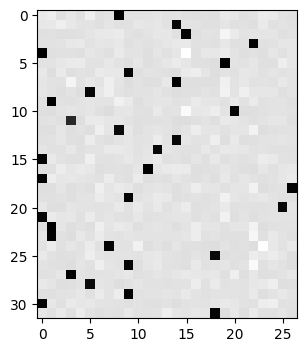

In [17]:
plt.figure(figsize=(4, 4))
plt.imshow(dlogits.detach(), cmap='gray')

下面将手动计算 batch norm 里的梯度反向传播的内容

In [18]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out

# 练习3：一次性完成批归一化的反向传播
# 完成这个挑战，需要观察批归一化输出的数学表达式，
# 对其输入求导、化简表达式，然后直接写出来

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True)        # 注意：贝塞尔校正（除以 n-1，而不是 n）
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(9.5367e-07, grad_fn=<MaxBackward1>)


将其与pytorch 计算出的值比对

In [19]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


In [20]:
dhprebn.shape, bngain.shape, bnvar_inv.shape, dbnraw.shape, dbnraw.sum(0).shape

(torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]),
 torch.Size([64]))

这一步我们将把上面的那些都整理集合在一起，进行综合运用，使用我们的自己的反向传播来训练MLP

In [21]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# 练习4：综合运用！
# 使用你自己的反向传播来训练这个多层感知机神经网络

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():

  # kick off optimization
  for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    # Linear layer
    hprebn = embcat @ W1 + b1 # hidden layer pre-activation
    # BatchNorm layer
    # -------------------------------------------------------------
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias
    # -------------------------------------------------------------
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
      p.grad = None
    #loss.backward() # use this for correctness comparisons, delete it later!

    # manual backprop! #swole_doge_meme
    # -----------------
    dlogits = F.softmax(logits, 1)
    dlogits[range(n), Yb] -= 1
    dlogits /= n
    # 2nd layer backprop
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    # tanh
    dhpreact = (1.0 - h**2) * dh
    # batchnorm backprop
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
    # 1st layer
    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    # embedding
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
      for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
    # -----------------

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p, grad in zip(parameters, grads):
      #p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
      p.data += -lr * grad # new way of swole doge TODO: enable

    # track stats
    if i % 10000 == 0: # print every once in a while
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

  #   if i >= 100: # TODO: delete early breaking when you're ready to train the full net
  #     break

12297
      0/ 200000: 3.8116
  10000/ 200000: 2.1846
  20000/ 200000: 2.4360
  30000/ 200000: 2.4966
  40000/ 200000: 2.0393
  50000/ 200000: 2.3119
  60000/ 200000: 2.4254
  70000/ 200000: 2.0215
  80000/ 200000: 2.3747
  90000/ 200000: 2.1830
 100000/ 200000: 2.0201
 110000/ 200000: 2.3981
 120000/ 200000: 1.9808
 130000/ 200000: 2.4464
 140000/ 200000: 2.2822
 150000/ 200000: 2.2273
 160000/ 200000: 1.9168
 170000/ 200000: 1.9101
 180000/ 200000: 2.0152
 190000/ 200000: 1.8454


In [22]:
# useful for checking your gradients
# for p,g in zip(parameters, grads):
#   cmp(str(tuple(p.shape)), g, p)

In [23]:
# calibrate the batch norm at the end of training
# 在训练结束时校准批归一化

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)


In [24]:
# evaluate train and val loss
# 评估训练和验证损失

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.070157289505005
val 2.1094303131103516


In [27]:
# I achieved:   这是karpathy的结果，训练损失2.07，验证损失2.11
# train 2.0718822479248047
# val 2.1162495613098145

In [26]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # ------------
      # forward pass:
      # Embedding
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # ------------
      # Sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carlah.
amori.
kitzimri.
reety.
salaysie.
mahnen.
delynn.
jareei.
ner.
kia.
chaiir.
kaleigh.
ham.
joce.
quinn.
saline.
liven.
coraelo.
dearyxia.
kael.


这里可以看到结果还是非常像名字的